# NB06: Overdispersion and Correlation Structure

Test for overdispersion in the Binomial model and assess temporal autocorrelation.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


In [2]:
try:
    tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
    print("Loaded nb04_target_features.csv:", tgt.shape)
except:
    tgt = pd.read_csv(DATA_DIR + 'nb01_target_daily_features.csv', parse_dates=['date'])
    wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
    target_wq = wq[(wq['region']=='Eluru')&(wq['Type']=='Morning')&(wq['Is follow up']=='No')].copy()
    target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
    target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')
    daily_out = target_wq.dropna(subset=['DO']).groupby('date').agg(
        n_total=('DO','count'), n_low=('DO', lambda x:(x<3).sum())
    ).reset_index()
    daily_out['frac_low'] = daily_out['n_low']/daily_out['n_total']
    tgt = tgt.merge(daily_out, on='date', how='inner')
    print("Recomputed:", tgt.shape)

import json
try:
    with open(DATA_DIR + 'nb04_selected_features.json') as f:
        feat_info = json.load(f)
    features = [f for f in feat_info['tgt_available'] if f in tgt.columns]
except:
    features = [c for c in tgt.columns if c not in ['date','n_total','n_low','frac_low','bad_day',
                'log_n_ponds','month','season','mean_do','n_ponds']]

print("Features:", features)

Loaded nb04_target_features.csv: (746, 11)
Features: ['month_sin', 'night_precip_sum', 'precip_2d_sum', 'doy_cos', 'night_wind_min']


## 2. Fit Binomial GLM

In [3]:
# Filter to rows with all features available
avail_feats = [f for f in features if f in tgt.columns]
analysis_df = tgt[['date','n_total','n_low','frac_low'] + avail_feats].dropna()
print(f"Analysis rows: {len(analysis_df)}")

if len(analysis_df) > 20 and len(avail_feats) > 0:
    # Standardize features
    X_raw = analysis_df[avail_feats].copy()
    X_std = (X_raw - X_raw.mean()) / X_raw.std().replace(0, 1)
    X_std = sm.add_constant(X_std)
    
    y = analysis_df[['n_low','n_total']].values
    
    try:
        binom_model = sm.GLM(
            y, X_std,
            family=sm.families.Binomial()
        ).fit()
        print(binom_model.summary())
    except Exception as e:
        print(f"GLM failed: {e}")
        # Fallback: use frac_low as continuous outcome
        binom_model = sm.OLS(analysis_df['frac_low'], X_std).fit()
        print("Fallback OLS model fitted")
else:
    print("Insufficient data for GLM")
    binom_model = None

Analysis rows: 746
                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  746
Model:                            GLM   Df Residuals:                      740
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -760.08
Date:                Sat, 25 Apr 2026   Deviance:                       1025.3
Time:                        16:35:41   Pearson chi2:                     990.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06732
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -

## 3. Overdispersion Test

In [4]:
if binom_model is not None:
    try:
        # Pearson chi-squared overdispersion test
        mu_hat = binom_model.predict()
        if hasattr(binom_model, 'model') and hasattr(binom_model.model, 'family'):
            n = analysis_df['n_total'].values
            p_hat = mu_hat
            pearson_resid = (analysis_df['n_low'].values - n * p_hat) / np.sqrt(n * p_hat * (1 - p_hat) + 1e-10)
            pearson_chi2 = np.sum(pearson_resid**2)
            df_resid = binom_model.df_resid
            dispersion = pearson_chi2 / df_resid
            print(f"Pearson chi-squared: {pearson_chi2:.2f}")
            print(f"Degrees of freedom: {df_resid:.0f}")
            print(f"Dispersion statistic (chi2/df): {dispersion:.3f}")
            if dispersion > 1.5:
                print("=> OVERDISPERSED! Recommend Beta-Binomial likelihood")
            elif dispersion > 1.0:
                print("=> Mild overdispersion detected")
            else:
                print("=> No overdispersion, Binomial likelihood acceptable")
        else:
            print("OLS model - computing residual stats")
            resid = binom_model.resid
            print(f"Residual std: {resid.std():.4f}")
    except Exception as e:
        print(f"Overdispersion test failed: {e}")

Pearson chi-squared: 1992.97
Degrees of freedom: 740
Dispersion statistic (chi2/df): 2.693
=> OVERDISPERSED! Recommend Beta-Binomial likelihood


## 4. Beta-Binomial MLE (estimate κ)

In [5]:
from scipy.special import betaln, gammaln, digamma

def beta_binomial_loglik(params, n, k, X):
    """Log-likelihood for Beta-Binomial regression."""
    beta_coef = params[:-1]
    log_kappa = params[-1]
    kappa = np.exp(log_kappa)
    
    eta = X @ beta_coef
    mu = 1 / (1 + np.exp(-eta))
    mu = np.clip(mu, 1e-6, 1-1e-6)
    
    alpha = mu * kappa
    beta_param = (1 - mu) * kappa
    
    ll = (gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1) +
          betaln(k + alpha, n - k + beta_param) - betaln(alpha, beta_param))
    return -np.sum(ll)

if len(analysis_df) > 20 and len(avail_feats) > 0:
    X_bb = sm.add_constant((X_raw - X_raw.mean()) / X_raw.std().replace(0,1)).values
    n_arr = analysis_df['n_total'].values.astype(float)
    k_arr = analysis_df['n_low'].values.astype(float)
    
    # Initial params
    n_params = X_bb.shape[1] + 1  # + log_kappa
    x0 = np.zeros(n_params)
    x0[-1] = np.log(10)  # initial kappa=10
    
    try:
        result = optimize.minimize(
            beta_binomial_loglik, x0, args=(n_arr, k_arr, X_bb),
            method='L-BFGS-B',
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        kappa_est = np.exp(result.x[-1])
        print(f"Beta-Binomial MLE convergence: {result.success}")
        print(f"Estimated κ (concentration): {kappa_est:.2f}")
        print(f"(κ→∞ means Binomial is fine; κ small means overdispersed)")
        if kappa_est < 20:
            print("=> Low κ: significant overdispersion, use Beta-Binomial")
        elif kappa_est < 100:
            print("=> Moderate κ: some overdispersion")
        else:
            print("=> High κ: Binomial is adequate")
    except Exception as e:
        print(f"BB MLE failed: {e}")
        kappa_est = None
else:
    kappa_est = None
    print("Insufficient data")

Beta-Binomial MLE convergence: True
Estimated κ (concentration): 1.40
(κ→∞ means Binomial is fine; κ small means overdispersed)
=> Low κ: significant overdispersion, use Beta-Binomial


## 5. ACF/PACF and Temporal Autocorrelation

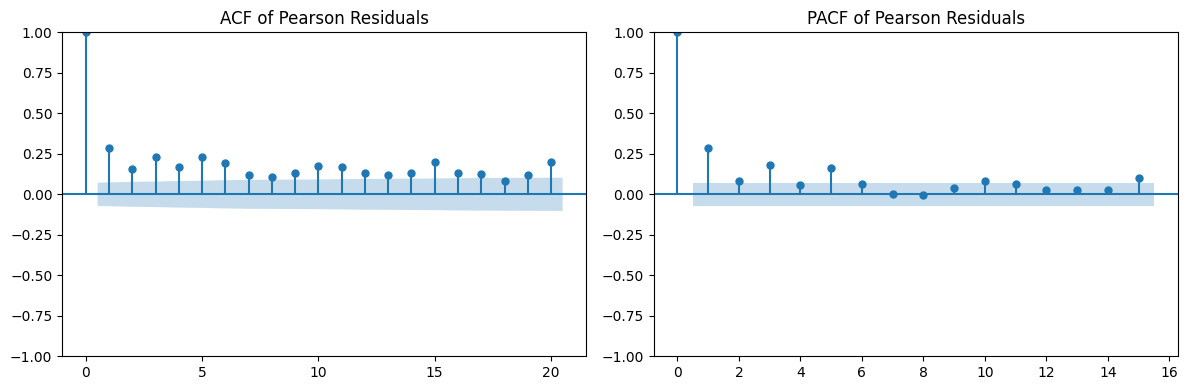

Ljung-Box test for autocorrelation:
       lb_stat     lb_pvalue
5   179.853110  5.751921e-37
10  262.894214  1.050402e-50
15  352.613596  5.967108e-66


In [6]:
if binom_model is not None:
    try:
        if hasattr(binom_model.resid_pearson, '__len__'):
            residuals = binom_model.resid_pearson
        else:
            residuals = binom_model.resid
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
        plot_acf(residuals, lags=min(20, len(residuals)//3), ax=axes[0], title='ACF of Pearson Residuals')
        plot_pacf(residuals, lags=min(15, len(residuals)//3), ax=axes[1], title='PACF of Pearson Residuals')
        
        plt.tight_layout()
        plt.savefig(OUT_DIR + 'nb06_residual_acf.png', dpi=80, bbox_inches='tight')
        plt.show()
        
        # Ljung-Box test
        lb_result = acorr_ljungbox(residuals, lags=[5, 10, 15], return_df=True)
        print("Ljung-Box test for autocorrelation:")
        print(lb_result)
    except Exception as e:
        print(f"ACF plot failed: {e}")

## 6-7. Residual Diagnostics & Observed vs Expected Variance

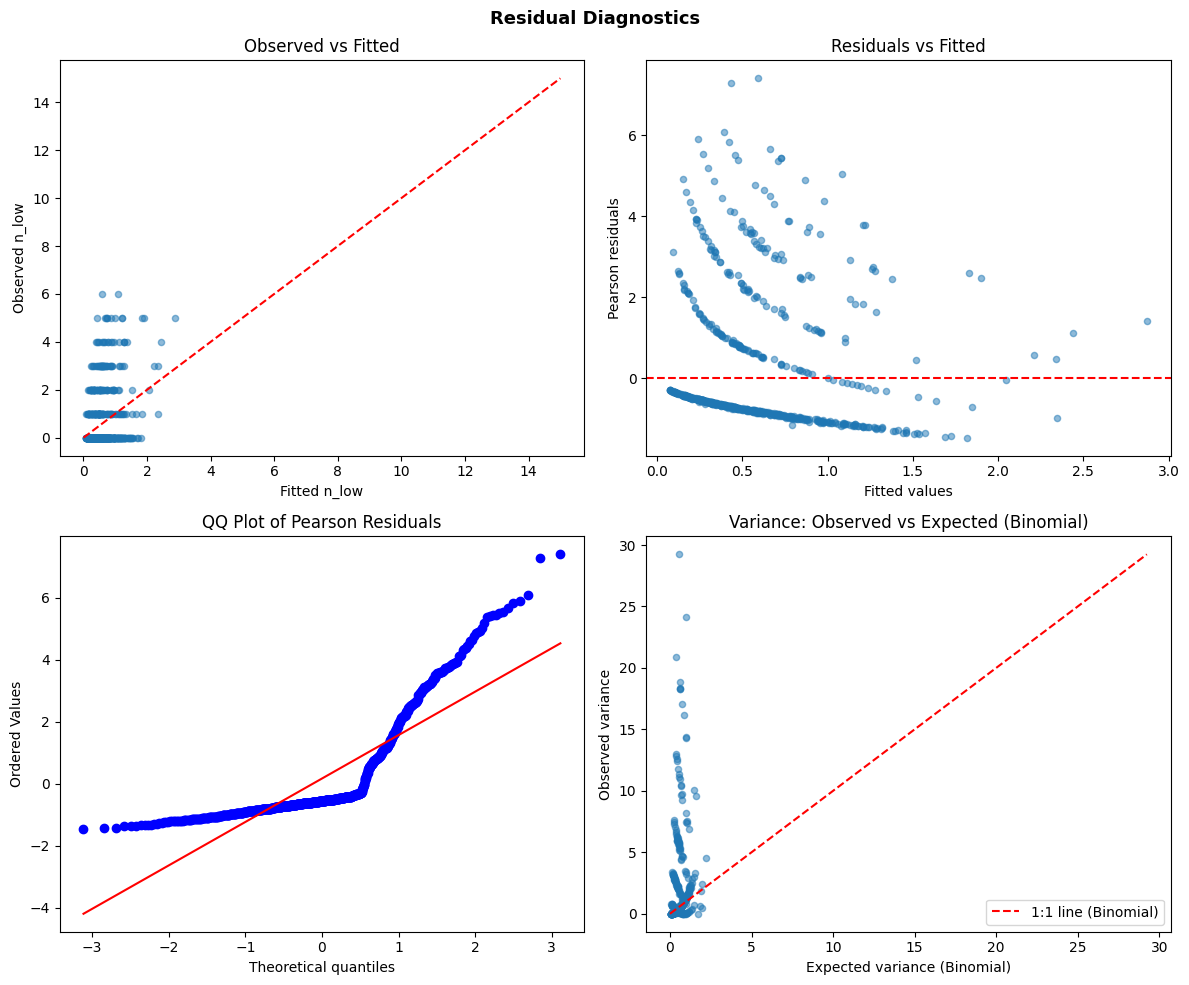

In [7]:
if binom_model is not None and len(analysis_df) > 0:
    try:
        mu_hat = binom_model.predict()
        n = analysis_df['n_total'].values
        k = analysis_df['n_low'].values
        
        # Expected vs observed variance
        p_hat = np.clip(mu_hat, 1e-6, 1-1e-6)
        expected_var_binom = n * p_hat * (1 - p_hat)
        observed_var = (k - n * p_hat)**2
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Observed vs fitted
        ax = axes[0, 0]
        ax.scatter(n * p_hat, k, alpha=0.5, s=20)
        mx = max(n.max(), k.max())
        ax.plot([0, mx], [0, mx], 'r--')
        ax.set_xlabel('Fitted n_low')
        ax.set_ylabel('Observed n_low')
        ax.set_title('Observed vs Fitted')
        
        # Residuals vs fitted
        ax = axes[0, 1]
        ax.scatter(n * p_hat, (k - n * p_hat) / np.sqrt(n * p_hat * (1-p_hat) + 1e-10), alpha=0.5, s=20)
        ax.axhline(0, color='red', linestyle='--')
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Pearson residuals')
        ax.set_title('Residuals vs Fitted')
        
        # QQ plot
        ax = axes[1, 0]
        res = (k - n * p_hat) / np.sqrt(n * p_hat * (1-p_hat) + 1e-10)
        stats.probplot(res, plot=ax)
        ax.set_title('QQ Plot of Pearson Residuals')
        
        # Expected vs observed variance
        ax = axes[1, 1]
        ax.scatter(expected_var_binom, observed_var, alpha=0.5, s=20)
        mx_v = max(expected_var_binom.max(), observed_var.max())
        ax.plot([0, mx_v], [0, mx_v], 'r--', label='1:1 line (Binomial)')
        ax.set_xlabel('Expected variance (Binomial)')
        ax.set_ylabel('Observed variance')
        ax.set_title('Variance: Observed vs Expected (Binomial)')
        ax.legend()
        
        plt.suptitle('Residual Diagnostics', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUT_DIR + 'nb06_residual_diagnostics.png', dpi=80, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Diagnostics plot failed: {e}")

In [8]:
print("=" * 60)
print("OVERDISPERSION RECOMMENDATION")
print("=" * 60)
if kappa_est is not None:
    print(f"Estimated Beta-Binomial κ = {kappa_est:.2f}")
    if kappa_est < 20:
        print("RECOMMENDATION: Use Beta-Binomial likelihood")
    else:
        print("RECOMMENDATION: Binomial likelihood acceptable, Beta-Binomial as robustness check")
else:
    print("Could not estimate κ; use Beta-Binomial as safe default")

OVERDISPERSION RECOMMENDATION
Estimated Beta-Binomial κ = 1.40
RECOMMENDATION: Use Beta-Binomial likelihood


## Iteration 2: AR(1) Residuals, Seasonal Heteroscedasticity, BetaBin vs Bin Residuals

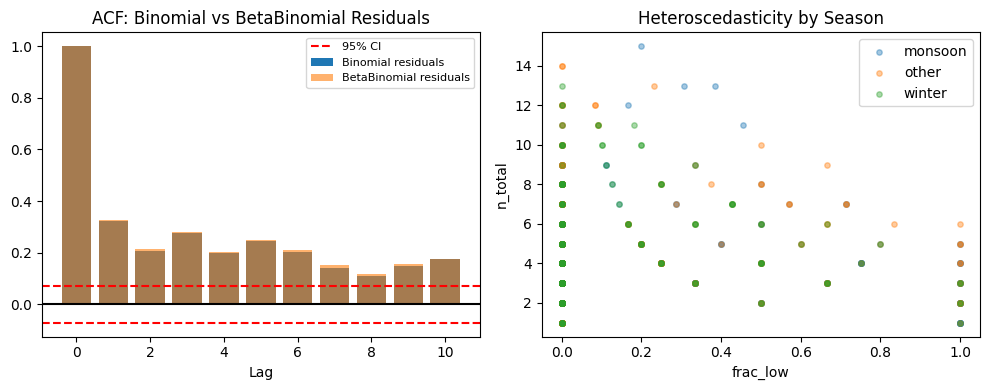

Binomial mu=0.144
BetaBinomial mu=0.157, kappa=1.31
Lag-1 ACF: Binomial=0.322, BetaBinomial=0.327


In [9]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import betabinom, binom
from scipy.optimize import minimize
from statsmodels.tsa.stattools import acf
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date']).sort_values('date')

tgt2 = tgt.dropna(subset=['frac_low','n_total']).copy()
n = tgt2['n_total'].astype(int).values
k = tgt2['n_low'].astype(int).values
valid = n > 0; n, k = n[valid], k[valid]
p_raw = k / np.clip(n, 1, None)

# Fit Binomial and BetaBinomial
def fit_model(model, k, n):
    if model == 'binomial':
        p_hat = k.sum() / n.sum()
        resid = k - n * p_hat
        return p_hat, None, resid
    else:
        def nll(params):
            mu = 1/(1+np.exp(-params[0])); kappa = np.exp(params[1])+1e-6
            a = mu*kappa; b = (1-mu)*kappa
            return -betabinom.logpmf(k, n, a, b).sum()
        res = minimize(nll, [0.0, np.log(5)], method='Nelder-Mead')
        mu = 1/(1+np.exp(-res.x[0])); kappa = np.exp(res.x[1])
        resid = k - n * mu
        return mu, kappa, resid

mu_bin, _, resid_bin = fit_model('binomial', k, n)
mu_bb, kappa_bb, resid_bb = fit_model('betabinom', k, n)

# ACF of residuals
acf_bin = acf(resid_bin, nlags=10, fft=True)
acf_bb  = acf(resid_bb,  nlags=10, fft=True)

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].bar(range(11), acf_bin, label='Binomial residuals')
axes[0].bar(range(11), acf_bb, alpha=0.6, label='BetaBinomial residuals')
axes[0].axhline(0, color='k'); axes[0].axhline(1.96/np.sqrt(len(k)), color='r', linestyle='--', label='95% CI')
axes[0].axhline(-1.96/np.sqrt(len(k)), color='r', linestyle='--')
axes[0].set_title('ACF: Binomial vs BetaBinomial Residuals'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('Lag')

# Seasonal heteroscedasticity
tgt3 = tgt.dropna(subset=['frac_low','n_total']).copy()
tgt3['season'] = pd.to_datetime(tgt3['date']).dt.month.map(lambda m: 'winter' if m in [12,1,2] else ('monsoon' if m in [6,7,8,9] else 'other'))
for season, grp in tgt3.groupby('season'):
    axes[1].scatter(grp['frac_low'], grp['n_total'], alpha=0.4, s=15, label=season)
axes[1].set_xlabel('frac_low'); axes[1].set_ylabel('n_total')
axes[1].set_title('Heteroscedasticity by Season'); axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR + 'nb06v2_ar1_seasonal.png', dpi=80, bbox_inches='tight')
plt.show()

print(f"Binomial mu={mu_bin:.3f}")
print(f"BetaBinomial mu={mu_bb:.3f}, kappa={kappa_bb:.2f}")
print(f"Lag-1 ACF: Binomial={acf_bin[1]:.3f}, BetaBinomial={acf_bb[1]:.3f}")


In [10]:
# ── AR(1) residuals model ────────────────────────────────────────────────────
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

resid = resid_bb  # use BetaBinomial residuals
resid_lag = np.roll(resid, 1); resid_lag[0] = 0

# Only consecutive dates
dates = tgt2[valid].reset_index(drop=True)['date'] if hasattr(tgt2[valid].reset_index(drop=True), '__getitem__') else pd.Series(range(len(resid)))

X_ar = sm.add_constant(resid_lag[1:])
model_ar = OLS(resid[1:], X_ar).fit()
phi = model_ar.params[1]
print(f"AR(1) coefficient φ = {phi:.3f} (p={model_ar.pvalues[1]:.4f})")
print(f"AR(1) R² = {model_ar.rsquared:.3f}")
if abs(phi) > 0.1 and model_ar.pvalues[1] < 0.05:
    print("  → Significant temporal autocorrelation — AR(1) correction recommended")
else:
    print("  → Temporal autocorrelation not significant after BetaBinomial")


AR(1) coefficient φ = 0.328 (p=0.0000)
AR(1) R² = 0.107
  → Significant temporal autocorrelation — AR(1) correction recommended
